Bussiness Questions
- What day of the week are vehicles most often and least often stolen?

- What types of vehicles are most often and least often stolen? Does this vary by region?

- What is the average age of the vehicles that are stolen? Does this vary based on the vehicle type?

- Which regions have the most and least number of stolen vehicles? What are the characteristics of the regions?

In [0]:
USE `motor-vehicle-theft`.vehicle_theft;

In [0]:
BEGIN TRANSACTION;

UPDATE stolen_vehicles 
SET vehicle_type = 'Roadbike'
WHERE Vehicle_id = 4537; 

UPDATE stolen_vehicles 
SET vehicle_type = 'Roadbike'
WHERE Vehicle_id = 4538; 

UPDATE stolen_vehicles 
SET vehicle_type = 'Roadbike'
WHERE Vehicle_id = 4531; 

UPDATE stolen_vehicles 
SET vehicle_type = 'Roadbike'
WHERE Vehicle_id = 4532; 

UPDATE stolen_vehicles 
SET vehicle_type = 'Saloon'
WHERE Vehicle_id = 4529; 

UPDATE stolen_vehicles 
SET vehicle_type = 'Saloon'
WHERE Vehicle_id = 4530; 

UPDATE stolen_vehicles 
SET vehicle_type = 'Hatchback'
WHERE Vehicle_id = 4533; 

UPDATE stolen_vehicles 
SET vehicle_type = 'Utility'
WHERE Vehicle_id = 4534; 

UPDATE stolen_vehicles 
SET vehicle_type = 'Utility'
WHERE Vehicle_id = 4536; 

UPDATE stolen_vehicles 
SET vehicle_type = 'Saloon'
WHERE Vehicle_id = 4535; 

SELECT vehicle_type FROM stolen_vehicles;

COMMIT; 


num_affected_rows
1


num_affected_rows
1


num_affected_rows
1


num_affected_rows
1


num_affected_rows
1


num_affected_rows
1


num_affected_rows
1


num_affected_rows
1


num_affected_rows
1


num_affected_rows
1


In [0]:
WITH Stolen_Vehicle_week AS (
SELECT
        dayname(date_stolen) as Name_of_Week
        ,Count(*) AS Stolen_Vehicles
        ,ROW_NUMBER () Over (Order by Count(*) DESC) AS  Ranking
FROM stolen_vehicles
GROUP BY 
         Name_of_Week
)
SELECT 
Name_of_Week
,Stolen_Vehicles
FROM Stolen_Vehicle_week
WHERE Ranking = '1';

Name_of_Week,Stolen_Vehicles
Mon,767


In [0]:
WITH Stolen_Vehicle_week AS (
SELECT
        dayname(date_stolen) as Name_of_Week
        ,Count(*) AS Stolen_Vehicles
        ,ROW_NUMBER () Over (Order by Count(*) ASC) AS  Ranking
FROM stolen_vehicles
GROUP BY 
         Name_of_Week
)
SELECT 
Name_of_Week
,Stolen_Vehicles
FROM Stolen_Vehicle_week
WHERE Ranking = '1';

Name_of_Week,Stolen_Vehicles
Sat,577


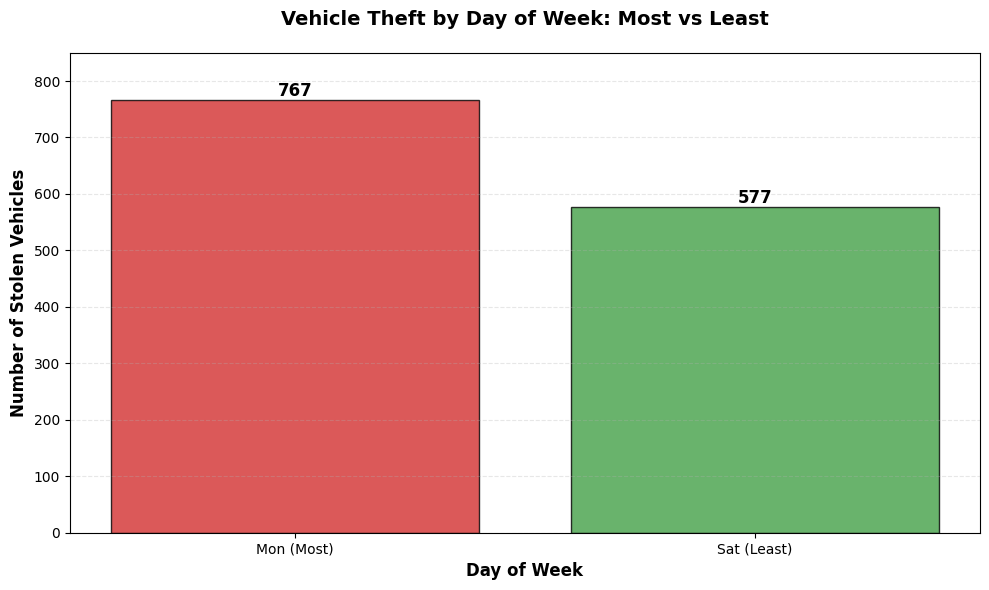

In [0]:
%python
import matplotlib.pyplot as plt
import pandas as pd

most_stolen_query = """
WITH Stolen_Vehicle_week AS (
    SELECT
        dayname(date_stolen) as Name_of_Week,
        Count(*) AS Stolen_Vehicles,
        ROW_NUMBER() OVER (Order by Count(*) DESC) AS Ranking
    FROM `motor-vehicle-theft`.vehicle_theft.stolen_vehicles
    GROUP BY Name_of_Week
)
SELECT Name_of_Week, Stolen_Vehicles
FROM Stolen_Vehicle_week
WHERE Ranking = '1'
"""

least_stolen_query = """
WITH Stolen_Vehicle_week AS (
    SELECT
        dayname(date_stolen) as Name_of_Week,
        Count(*) AS Stolen_Vehicles,
        ROW_NUMBER() OVER (Order by Count(*) ASC) AS Ranking
    FROM `motor-vehicle-theft`.vehicle_theft.stolen_vehicles
    GROUP BY Name_of_Week
)
SELECT Name_of_Week, Stolen_Vehicles
FROM Stolen_Vehicle_week
WHERE Ranking = '1'
"""

most_stolen_df = spark.sql(most_stolen_query).toPandas()
least_stolen_df = spark.sql(least_stolen_query).toPandas()

# Combine data
days_data = {
    'Day': [f"{most_stolen_df.iloc[0]['Name_of_Week']} (Most)", 
            f"{least_stolen_df.iloc[0]['Name_of_Week']} (Least)"],
    'Stolen_Vehicles': [most_stolen_df.iloc[0]['Stolen_Vehicles'], 
                       least_stolen_df.iloc[0]['Stolen_Vehicles']]
}

df = pd.DataFrame(days_data)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d32f2f', '#43a047']
bars = ax.bar(df['Day'], df['Stolen_Vehicles'], color=colors, alpha=0.8, edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Stolen Vehicles', fontsize=12, fontweight='bold')
ax.set_title('Vehicle Theft by Day of Week: Most vs Least', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 850)

plt.tight_layout()
display(plt.show())

What types of vehicles are most often and least often stolen? Does this vary by region?

In [0]:

SELECT 
        Vehicle_type
        ,COUNT(*) As Number_of_Accidents
FROM stolen_vehicles s 
INNER JOIN make_details m
ON s.make_id = m.make_id
GROUP BY Vehicle_type
ORDER BY Number_of_Accidents DESC 
LIMIT 5;




Vehicle_type,Number_of_Accidents
Stationwagon,944
Saloon,854
Hatchback,645
Trailer,582
Utility,468


Databricks visualization. Run in Databricks to view.

In [0]:
SELECT 
        Vehicle_type
        ,COUNT(*) As Number_of_Accidents
FROM stolen_vehicles s 
INNER JOIN make_details m
ON s.make_id = m.make_id
GROUP BY Vehicle_type
ORDER BY Number_of_Accidents ASC 
LIMIT 5;

Vehicle_type,Number_of_Accidents
Articulated Truck,1
Special Purpose Vehicle,1
Trail Bike,2
Mobile Machine,2
Tractor,4


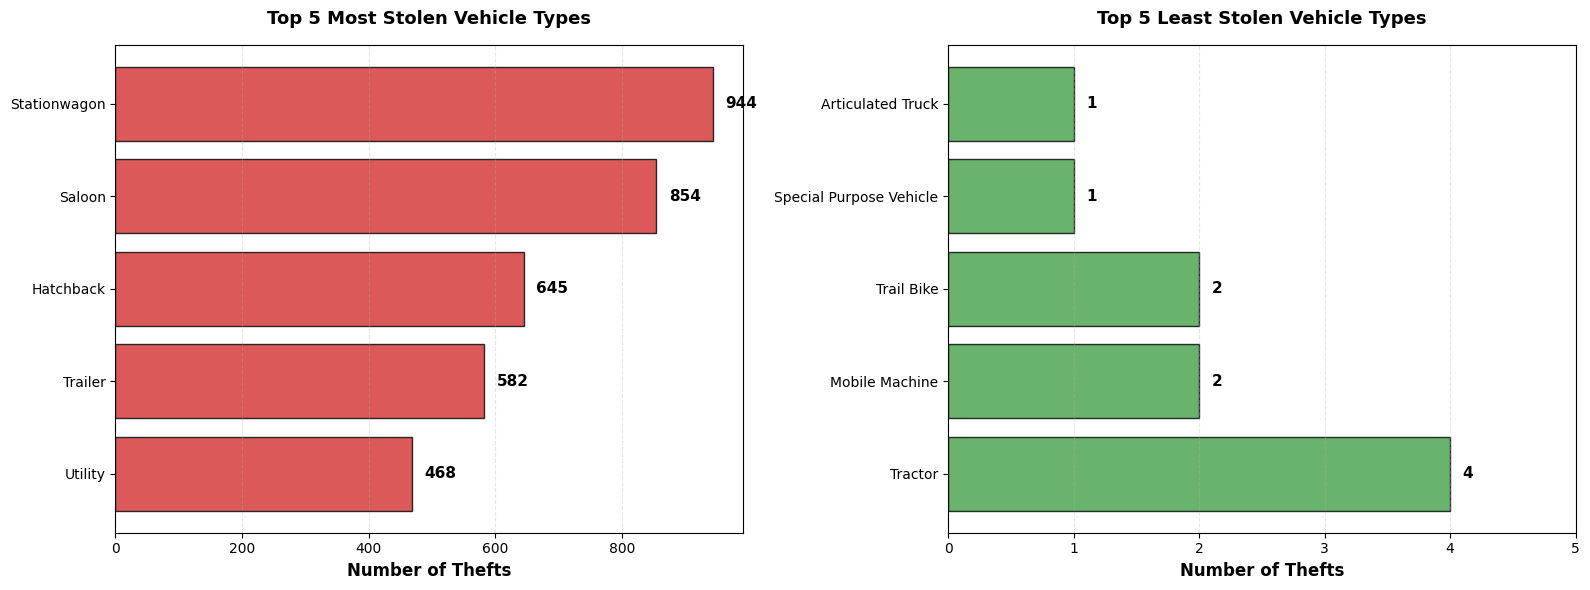

In [0]:
%python
import matplotlib.pyplot as plt
import pandas as pd

most_stolen_query = """
SELECT 
    Vehicle_type,
    COUNT(*) As Number_of_Accidents
FROM `motor-vehicle-theft`.vehicle_theft.stolen_vehicles s 
INNER JOIN `motor-vehicle-theft`.vehicle_theft.make_details m ON s.make_id = m.make_id
GROUP BY Vehicle_type
ORDER BY Number_of_Accidents DESC 
LIMIT 5
"""

least_stolen_query = """
SELECT 
    Vehicle_type,
    COUNT(*) As Number_of_Accidents
FROM `motor-vehicle-theft`.vehicle_theft.stolen_vehicles s 
INNER JOIN `motor-vehicle-theft`.vehicle_theft.make_details m ON s.make_id = m.make_id
GROUP BY Vehicle_type
ORDER BY Number_of_Accidents ASC 
LIMIT 5
"""
most_stolen = spark.sql(most_stolen_query).toPandas()
most_stolen.columns = ['Vehicle_type', 'Count']

least_stolen = spark.sql(least_stolen_query).toPandas()
least_stolen.columns = ['Vehicle_type', 'Count']

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Most Stolen (left subplot)
ax1.barh(most_stolen['Vehicle_type'], most_stolen['Count'], color='#d32f2f', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Number of Thefts', fontsize=12, fontweight='bold')
ax1.set_title('Top 5 Most Stolen Vehicle Types', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.invert_yaxis()

# Add value labels
for i, v in enumerate(most_stolen['Count']):
    ax1.text(v + 20, i, str(v), va='center', fontweight='bold', fontsize=11)

# Least Stolen (right subplot)
ax2.barh(least_stolen['Vehicle_type'], least_stolen['Count'], color='#43a047', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Number of Thefts', fontsize=12, fontweight='bold')
ax2.set_title('Top 5 Least Stolen Vehicle Types', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.invert_yaxis()
ax2.set_xlim(0, 5)

# Add value labels
for i, v in enumerate(least_stolen['Count']):
    ax2.text(v + 0.1, i, str(v), va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
display(plt.show())

In [0]:
WITH stolen_cars_by_region AS (
SELECT 
l.region
        , vehicle_type
        , COUNT(*) AS Number_of_Stolen_Cars
        , ROW_NUMBER() OVER(PARTITION BY l.region ORDER BY COUNT(*) DESC) AS Rank
FROM stolen_vehicles s 
INNER JOIN make_details m
ON s.make_id = m.make_id
INNER JOIN locations l  
ON s.location_id = l.location_id
GROUP BY l.region, vehicle_type
ORDER BY l.region, Number_of_Stolen_Cars DESC
)
SELECT region
        ,vehicle_type
        ,Number_of_Stolen_Cars
FROM stolen_cars_by_region
WHERE Rank <=3;

region,vehicle_type,Number_of_Stolen_Cars
Auckland,Saloon,330
Auckland,Stationwagon,306
Auckland,Hatchback,296
Bay of Plenty,Utility,100
Bay of Plenty,Saloon,86
Bay of Plenty,Stationwagon,79
Canterbury,Stationwagon,164
Canterbury,Trailer,128
Canterbury,Saloon,99
Gisborne,Saloon,41


Databricks visualization. Run in Databricks to view.

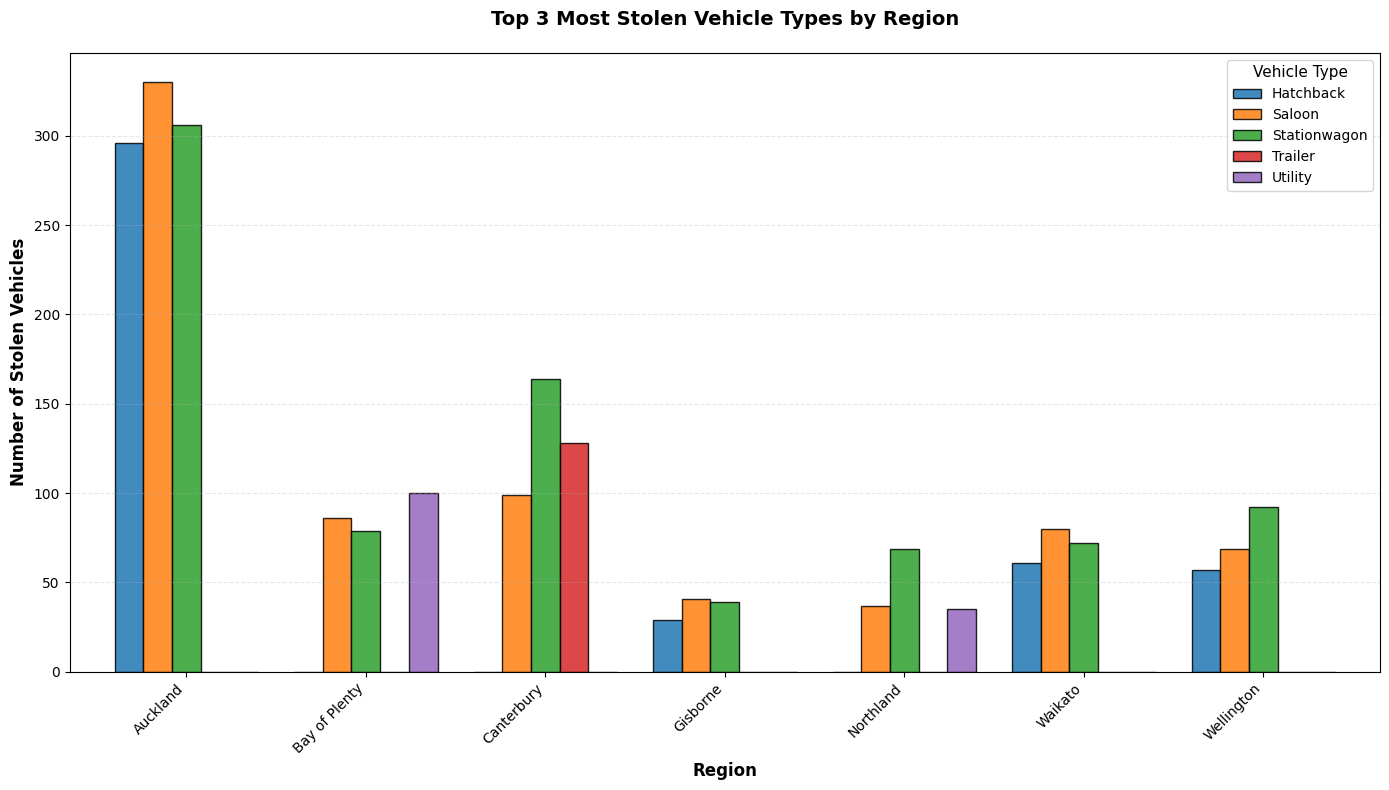

In [0]:
%python
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

regional_query = """
WITH stolen_cars_by_region AS (
    SELECT 
        l.region,
        vehicle_type,
        COUNT(*) AS Number_of_Stolen_Cars,
        ROW_NUMBER() OVER(PARTITION BY l.region ORDER BY COUNT(*) DESC) AS Rank
    FROM `motor-vehicle-theft`.vehicle_theft.stolen_vehicles s 
    INNER JOIN `motor-vehicle-theft`.vehicle_theft.make_details m ON s.make_id = m.make_id
    INNER JOIN `motor-vehicle-theft`.vehicle_theft.locations l ON s.location_id = l.location_id
    GROUP BY l.region, vehicle_type
)
SELECT region, vehicle_type, Number_of_Stolen_Cars
FROM stolen_cars_by_region
WHERE Rank <= 3
ORDER BY region, Number_of_Stolen_Cars DESC
"""

df = spark.sql(regional_query).toPandas()
df.columns = ['Region', 'Vehicle_Type', 'Count']

# Focus on top 7 regions by total thefts
top_regions = ['Auckland', 'Canterbury', 'Wellington', 'Waikato', 'Bay of Plenty', 'Northland', 'Gisborne']
df_filtered = df[df['Region'].isin(top_regions)]

# Pivot for grouped bar chart
df_pivot = df_filtered.pivot(index='Region', columns='Vehicle_Type', values='Count').fillna(0)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 8))
df_pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', alpha=0.85)

ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Stolen Vehicles', fontsize=12, fontweight='bold')
ax.set_title('Top 3 Most Stolen Vehicle Types by Region', fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Vehicle Type', title_fontsize=11, fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
display(plt.show())

What is the average age of the vehicles that are stolen? Does this vary based on the vehicle type?

In [0]:
SELECT 
    ROUND(AVG(YEAR(date_stolen) 
    - Try_cast(model_year AS bigint)),0) AS avg_vehicle_age_at_theft 
FROM stolen_vehicles
WHERE vehicle_type IS NOT NULL
ORDER BY avg_vehicle_age_at_theft DESC;

avg_vehicle_age_at_theft
16.0


In [0]:
SELECT 
    vehicle_type,
    ROUND(AVG(YEAR(date_stolen) 
    - Try_cast(model_year AS bigint)),0) AS avg_vehicle_age_at_theft 
FROM stolen_vehicles
WHERE vehicle_type IS NOT NULL
GROUP BY vehicle_type
ORDER BY avg_vehicle_age_at_theft DESC;

vehicle_type,avg_vehicle_age_at_theft
Special Purpose Vehicle,64.0
Mobile Home - Light,35.0
Caravan,28.0
Flat Deck Truck,28.0
Convertible,23.0
Heavy Van,23.0
Other Truck,23.0
Sports Car,22.0
Trail Bike,21.0
Saloon,19.0


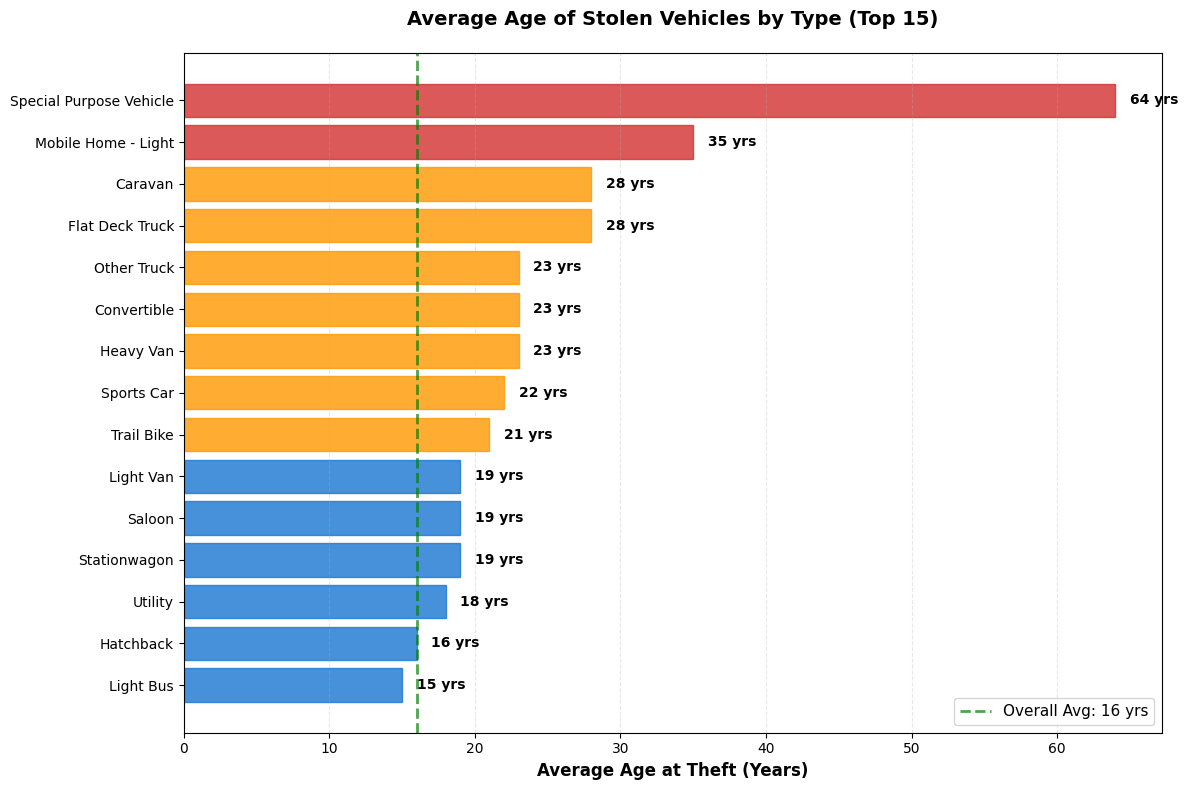

In [0]:
%python
import matplotlib.pyplot as plt
import pandas as pd

age_query = """
SELECT 
    vehicle_type,
    ROUND(AVG(YEAR(date_stolen) - TRY_CAST(model_year AS bigint)), 0) AS avg_vehicle_age_at_theft 
FROM `motor-vehicle-theft`.vehicle_theft.stolen_vehicles
WHERE vehicle_type IS NOT NULL
GROUP BY vehicle_type
ORDER BY avg_vehicle_age_at_theft DESC
LIMIT 15
"""

overall_avg_query = """
SELECT 
    ROUND(AVG(YEAR(date_stolen) - TRY_CAST(model_year AS bigint)), 0) AS avg_vehicle_age_at_theft 
FROM `motor-vehicle-theft`.vehicle_theft.stolen_vehicles
WHERE vehicle_type IS NOT NULL
"""

# Execute queries
df = spark.sql(age_query).toPandas()
df.columns = ['Vehicle_Type', 'Avg_Age']

overall_avg = spark.sql(overall_avg_query).toPandas().iloc[0]['avg_vehicle_age_at_theft']

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df['Vehicle_Type'], df['Avg_Age'], color='#1976d2', alpha=0.8, edgecolor='black')

# Color gradient based on age
for i, bar in enumerate(bars):
    if df.iloc[i]['Avg_Age'] >= 30:
        bar.set_color('#d32f2f')  # Red for very old
    elif df.iloc[i]['Avg_Age'] >= 20:
        bar.set_color('#ff9800')  # Orange for old
    else:
        bar.set_color('#1976d2')  # Blue for newer

ax.set_xlabel('Average Age at Theft (Years)', fontsize=12, fontweight='bold')
ax.set_title('Average Age of Stolen Vehicles by Type (Top 15)', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()

# Add value labels
for i, v in enumerate(df['Avg_Age']):
    ax.text(v + 1, i, f'{int(v)} yrs', va='center', fontweight='bold', fontsize=10)

# Add reference line for overall average (from cell 14)
ax.axvline(x=overall_avg, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Overall Avg: {int(overall_avg)} yrs')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
display(plt.show())

Which regions have the most and least number of stolen vehicles? What are the characteristics of the regions?

In [0]:
SELECT 
l.region
        , COUNT(*) AS Number_of_Stolen_Cars
        ,ROUND(COUNT(*)/population * 1000,2) As Rate_per_Population
FROM stolen_vehicles s 
INNER JOIN make_details m
ON s.make_id = m.make_id
INNER JOIN locations l  
ON s.location_id = l.location_id
GROUP BY l.region, population
ORDER BY Number_of_Stolen_Cars DESC;

region,Number_of_Stolen_Cars,Rate_per_Population
Auckland,1630,0.96
Canterbury,660,1.01
Bay of Plenty,445,1.28
Wellington,417,0.77
Waikato,369,0.72
Northland,234,1.16
Gisborne,175,3.36
Otago,139,0.57
Manawatū-Whanganui,139,0.54
Taranaki,112,0.88


Databricks visualization. Run in Databricks to view.

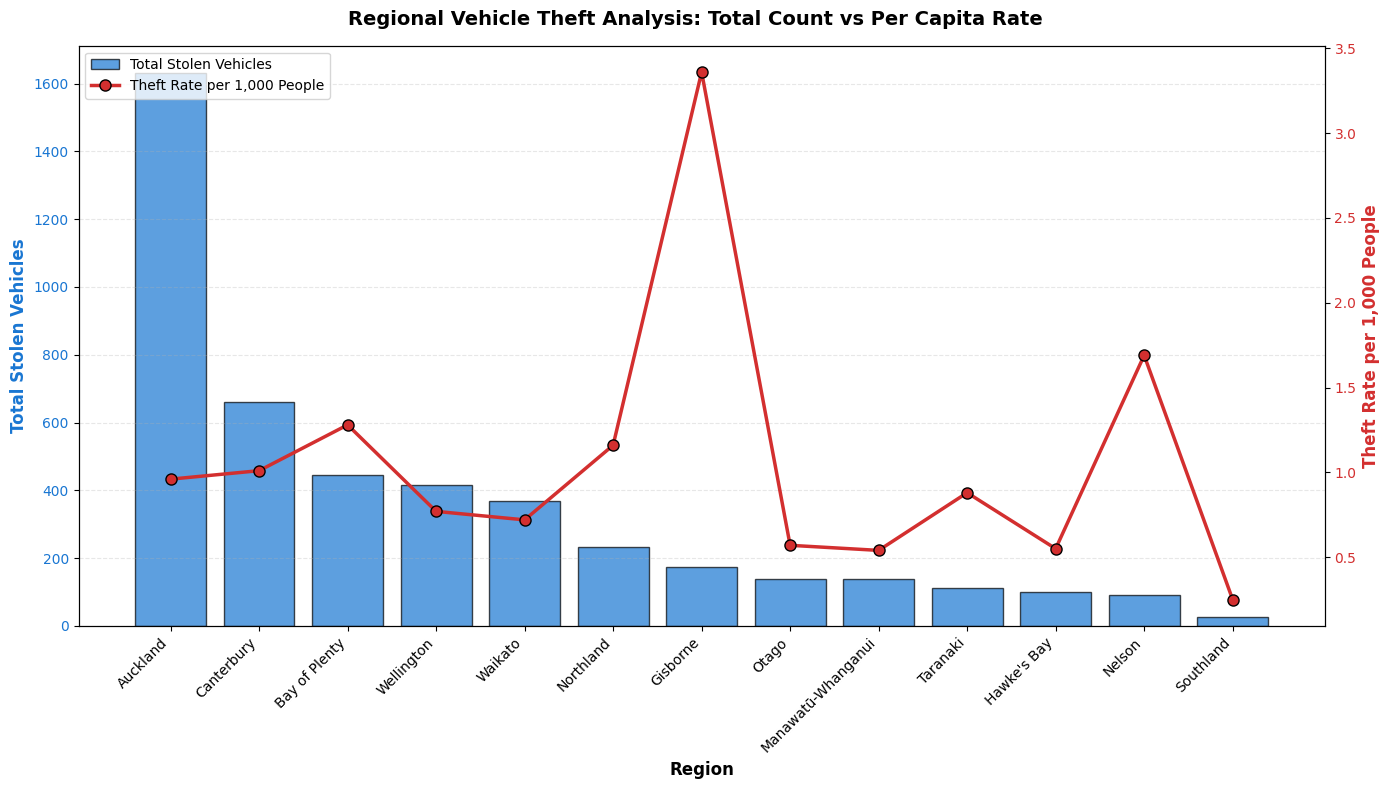

In [0]:
%python
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

regional_query = """
SELECT 
    l.region,
    COUNT(*) AS Number_of_Stolen_Cars,
    ROUND(COUNT(*)/population * 1000, 2) As Rate_per_Population
FROM `motor-vehicle-theft`.vehicle_theft.stolen_vehicles s 
INNER JOIN `motor-vehicle-theft`.vehicle_theft.make_details m ON s.make_id = m.make_id
INNER JOIN `motor-vehicle-theft`.vehicle_theft.locations l ON s.location_id = l.location_id
GROUP BY l.region, population
ORDER BY Number_of_Stolen_Cars DESC
"""

df = spark.sql(regional_query).toPandas()
df.columns = ['Region', 'Total_Thefts', 'Rate_per_1000']

fig, ax1 = plt.subplots(figsize=(14, 8))

x = np.arange(len(df))
ax1.bar(x, df['Total_Thefts'], color='#1976d2', alpha=0.7, edgecolor='black', label='Total Stolen Vehicles')
ax1.set_xlabel('Region', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Stolen Vehicles', fontsize=12, fontweight='bold', color='#1976d2')
ax1.tick_params(axis='y', labelcolor='#1976d2')
ax1.set_xticks(x)
ax1.set_xticklabels(df['Region'], rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

ax2 = ax1.twinx()
ax2.plot(x, df['Rate_per_1000'], color='#d32f2f', marker='o', linewidth=2.5, 
         markersize=8, label='Theft Rate per 1,000 People', markeredgecolor='black', markeredgewidth=1)
ax2.set_ylabel('Theft Rate per 1,000 People', fontsize=12, fontweight='bold', color='#d32f2f')
ax2.tick_params(axis='y', labelcolor='#d32f2f')

fig.suptitle('Regional Vehicle Theft Analysis: Total Count vs Per Capita Rate', 
             fontsize=14, fontweight='bold', y=0.98)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
display(plt.show())

# Motor Vehicle Theft Analysis: Key Findings & Business Insights

---

## Executive Summary

This analysis examined **4,538 stolen vehicles** across New Zealand to identify temporal patterns, vehicle characteristics, and regional variations in vehicle theft.

---

## Business Questions Answered

### **What day of the week are vehicles most often and least often stolen?**

**Most Stolen:** **Monday** with **767 thefts** (16.9% of weekly thefts).

**Least Stolen:** **Saturday** with **577 thefts** (12.7% of weekly thefts).

**Insight:** Vehicle thefts are **33% higher on Mondays** than Saturdays. This suggests:
* Weekday/work-related parking patterns create more opportunities.
* Vehicles left in commuter lots or workplaces are more vulnerable.

**Recommendation:** Increase patrol and surveillance in business districts and commuter parking areas on Mondays.

---

###  **What types of vehicles are most often and least often stolen? Does this vary by region?**

#### **Most Stolen Vehicle Types (Nationally):**
1. **Stationwagon:** 944 thefts (20.8%)
2. **Saloon:** 854 thefts (18.8%)
3. **Hatchback:** 645 thefts (14.2%)
4. **Trailer:** 582 thefts (12.8%)
5. **Utility:** 468 thefts (10.3%)

#### **Least Stolen Vehicle Types:**
1. **Articulated Truck:** 1 theft
2. **Special Purpose Vehicle:** 1 theft
3. **Trail Bike:** 2 thefts
4. **Mobile Machine:** 2 thefts
5. **Tractor:** 4 thefts

#### **Regional Variations:**

**Urban Regions (Auckland, Wellington, Canterbury):**
* Prefer **Stationwagons** and **Saloons** (family/commuter vehicles)
* High **Hatchback** thefts (compact, easy to steal)

**Rural/Semi-Rural Regions (Bay of Plenty, Northland):**
* Higher proportion of **Utilities** stolen
* Reflects regional vehicle ownership patterns

**Canterbury:**
* **Trailer thefts** are #2 (128 thefts)
* Likely due to agricultural/construction equipment

**Insight:** Thieves target **common, easily resold vehicles**. Specialized vehicles (trucks, tractors) are rarely stolen due to:
* Lower resale market
* Harder to transport/conceal
* Better security/tracking systems

---

### **What is the average age of stolen vehicles? Does this vary by vehicle type?**

**Overall Average Age:** **16 years**

#### **Vehicle Types Targeted by Age:**

**Older Vehicles Targeted (High Theft Risk):**
* **Special Purpose Vehicle:** 64 years (niche/specialty)
* **Mobile Home - Light:** 35 years
* **Caravan:** 28 years
* **Convertible/Heavy Van/Other Truck:** 23 years

**Mid-Age Vehicles (Moderate Risk):**
* **Saloon/Stationwagon:** 19 years (most common stolen types)
* **Utility:** 18 years
* **Hatchback:** 16 years (aligns with overall average)

**Newer Vehicles Targeted (Lower Average Age):**
* **Mobile Machine:** 4 years
* **Moped/Tractor:** 7 years
* **Roadbike:** 10 years
* **Trailer:** 11 years

**Critical Insight:** 
* **Older vehicles (15-20 years) are primary targets** because:
  * Weaker security systems (no immobilizers, GPS tracking)
  * Easier to hotwire/steal
  * High market for parts
  * Lower VIN tracking/recovery rates
* **Newer vehicles** (Mobile Machines, Mopeds) stolen for different reasons:
  * High resale value when new
  * Easy to transport (motorcycles, small equipment)

**Recommendation:** 
* Target awareness campaigns at owners of 15-20 year old Stationwagons, Saloons, and Hatchbacks
* Promote aftermarket security systems for older vehicles

---

###  **Which regions have the most/least stolen vehicles? What are the characteristics?**

#### **Regions by Absolute Theft Count:**

**Highest:**
1. **Auckland:** 1,630 thefts (35.9%)
2. **Canterbury:** 660 thefts (14.5%)
3. **Bay of Plenty:** 445 thefts (9.8%)

**Lowest:**
1. **Southland:** 26 thefts (0.6%)
2. **Nelson:** 92 thefts (2.0%)
3. **Hawke's Bay:** 100 thefts (2.2%)

#### **Regions by Per Capita Theft Rate (per 1,000 people):**

**Highest Risk Regions:**
1. **Gisborne:** 3.36 per 1,000 -- **High**
2. **Nelson:** 1.69 per 1,000
3. **Bay of Plenty:** 1.28 per 1,000
4. **Northland:** 1.16 per 1,000
5. **Canterbury:** 1.01 per 1,000

**Lowest Risk Regions:**
1. **Southland:** 0.25 per 1,000
2. **Manawatū-Whanganui:** 0.54 per 1,000
3. **Hawke's Bay:** 0.55 per 1,000


---

## Summary Statistics

* **Total Vehicles Analyzed:** 4,538
* **Peak Theft Day:** Monday (767 thefts)
* **Most Stolen Type:** Stationwagon (944 thefts)
* **Average Vehicle Age:** 16 years
* **Highest Risk Region:** Gisborne (3.36 per 1,000)
* **Most Thefts :** Auckland (1,630 thefts)
* **Safest Region:** Southland (0.25 per 1,000)
